In [2]:
import os 
os.environ["OMP_NUM_THREADS"] = "3"

In [3]:
# Level 1 - Task 1: Data Cleaning and Preprocessing

In [4]:
import pandas as pd

# Load the dataset

df = pd.read_csv('Sentiment dataset.csv')

print("Shape before cleaning:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape before cleaning: (732, 15)

Column names: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
# Drop unnecessary index columns

print("Before dropping columns:", df.columns.tolist())

# Drop the unnamed index columns (leftover from export)
cols_to_drop = [c for c in df.columns if 'Unnamed' in c]
df = df.drop(columns=cols_to_drop)

print("After dropping columns:", df.columns.tolist())

Before dropping columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
After dropping columns: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [6]:
# Check and handle missing values

print("Missing values before handling:\n", df.isnull().sum())

# Drop rows where Text or Sentiment is missing (core columns for NLP task)
df = df.dropna(subset=['Text', 'Sentiment'])

# For numeric engagement columns, fill missing with 0 (no retweets/likes recorded)
df['Retweets'] = df['Retweets'].fillna(0)
df['Likes'] = df['Likes'].fillna(0)

print("\nMissing values after handling:\n", df.isnull().sum())

Missing values before handling:
 Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

Missing values after handling:
 Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


In [7]:
# Remove duplicate rows

print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

Duplicate rows before removal: 20
Duplicate rows after removal: 0
Shape after removing duplicates: (712, 13)


In [8]:
# Standardize data formats

# Convert Timestamp to proper datetime
print("Timestamp dtype before:", df['Timestamp'].dtype)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("Timestamp dtype after:", df['Timestamp'].dtype)

# Standardize categorical text casing (Title Case) for consistency
df['Sentiment'] = df['Sentiment'].str.title()
df['Platform'] = df['Platform'].str.title()
df['Country'] = df['Country'].str.title()

# Convert Retweets/Likes to integers (they're counts, not decimals)
df['Retweets'] = df['Retweets'].astype(int)
df['Likes'] = df['Likes'].astype(int)

print("\nFinal dtypes:\n", df.dtypes)

Timestamp dtype before: object
Timestamp dtype after: datetime64[ns]

Final dtypes:
 Text                 object
Sentiment            object
Timestamp    datetime64[ns]
User                 object
Platform             object
Hashtags             object
Retweets              int64
Likes                 int64
Country              object
Year                  int64
Month                 int64
Day                   int64
Hour                  int64
dtype: object


In [9]:
# Final check

print("Final shape:", df.shape)
print("\nUnique Platforms:", df['Platform'].unique())
df.head()

Final shape: (712, 13)

Unique Platforms: [' Twitter  ' ' Instagram ' ' Facebook ' ' Twitter ']


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,Usa,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,Usa,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,Uk,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [10]:
# Save the cleaned dataset
df.to_csv("sentiment_dataset_cleaned.csv", index=False)
print("Saved as 'sentiment_dataset_cleaned.csv'")

Saved as 'sentiment_dataset_cleaned.csv'


In [11]:
# Level 1 - Task 2: Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Summary statistics - numerical columns

print("Summary statistics (numerical columns):")
df[['Retweets', 'Likes']].describe()

Summary statistics (numerical columns):


,Retweets,Likes
count,712.000000,712.000000
mean,21.542135,42.966292
std,7.124840,14.215995
min,5.000000,10.000000
25%,17.750000,34.750000
50%,22.000000,43.000000
75%,25.000000,50.000000
max,40.000000,80.000000


In [14]:
# Mean, median, mode, std for key numeric columns
for col in ['Retweets', 'Likes']:
    print(f"--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std Dev:", df[col].std())
    print()

--- Retweets ---
Mean: 21.542134831460675
Median: 22.0
Mode: 22
Std Dev: 7.124839767246677

--- Likes ---
Mean: 42.96629213483146
Median: 43.0
Mode: 45
Std Dev: 14.215994587981081



In [15]:
# Categorical summary
print("Sentiment value counts:")
print(df['Sentiment'].value_counts())

print("\nPlatform value counts:")
print(df['Platform'].value_counts())

print("\nTop 10 Countries:")
print(df['Country'].value_counts().head(10))

Sentiment value counts:
Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Happy              14
                   ..
Dazzle              1
Adrenaline          1
Harmony             1
Artisticburst       1
Elegance            1
Name: count, Length: 279, dtype: int64

Platform value counts:
Platform
Instagram     252
Facebook      224
Twitter       122
Twitter       114
Name: count, dtype: int64

Top 10 Countries:
Country
Usa               59
Usa               51
Uk                49
Canada            44
Australia         36
Canada            31
Uk                30
Usa               20
India             19
Canada            17
Name: count, dtype: int64


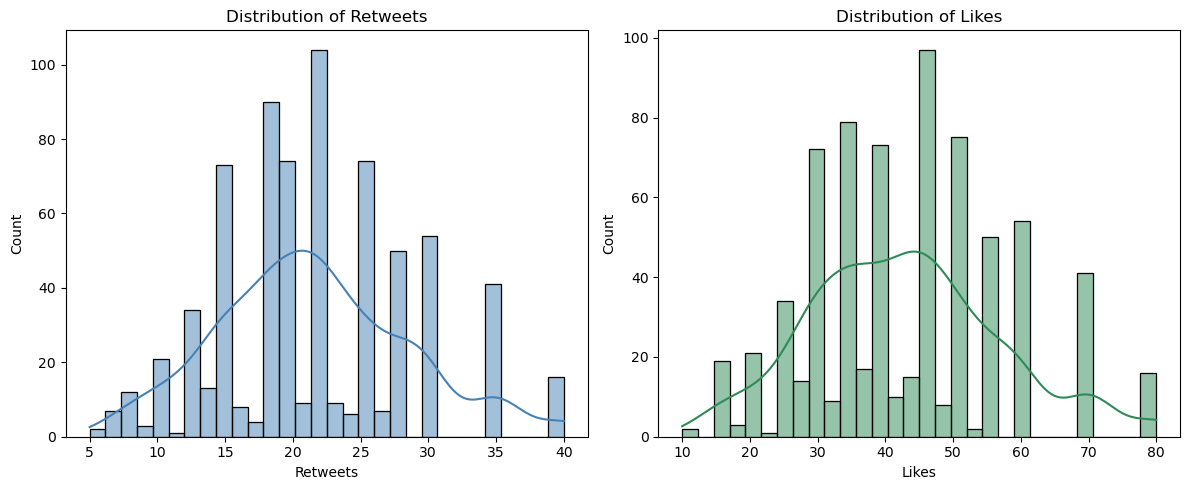

In [16]:
# Distribution: Histograms

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Retweets'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Retweets')

sns.histplot(df['Likes'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Likes')

plt.tight_layout()
plt.show()

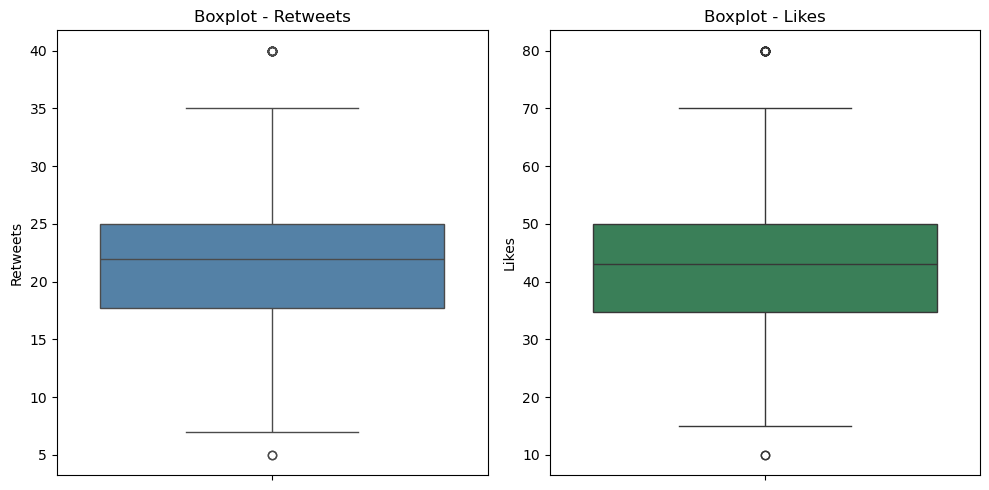

In [17]:
# Distribution: Boxplots (check for outliers)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=df['Retweets'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot - Retweets')

sns.boxplot(y=df['Likes'], ax=axes[1], color='seagreen')
axes[1].set_title('Boxplot - Likes')

plt.tight_layout()
plt.show()

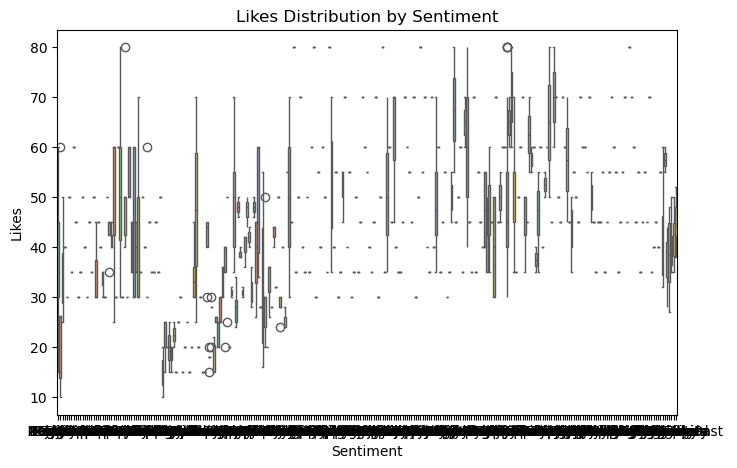

In [18]:
# Boxplot: Likes by Sentiment (categorical vs numerical)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sentiment', y='Likes', hue='Sentiment', palette='Set2', legend=False)
plt.title('Likes Distribution by Sentiment')
plt.show()

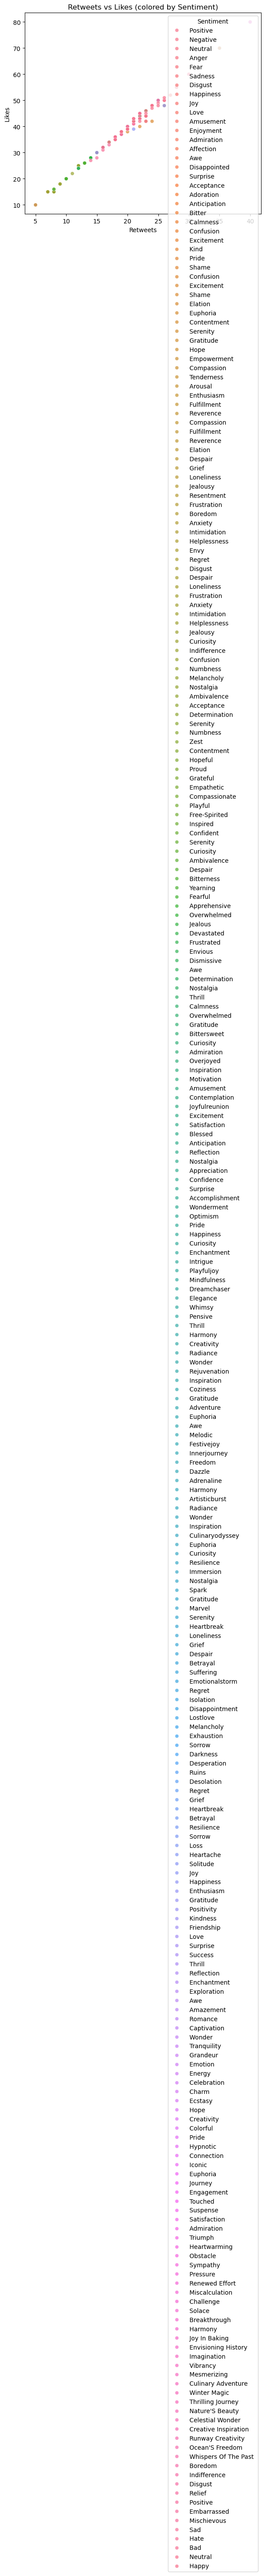

In [19]:
# Scatter plot: Retweets vs Likes

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Retweets', y='Likes', hue='Sentiment', alpha=0.7)
plt.title('Retweets vs Likes (colored by Sentiment)')
plt.show()

Correlation matrix:
          Retweets     Likes
Retweets  1.000000  0.998475
Likes     0.998475  1.000000


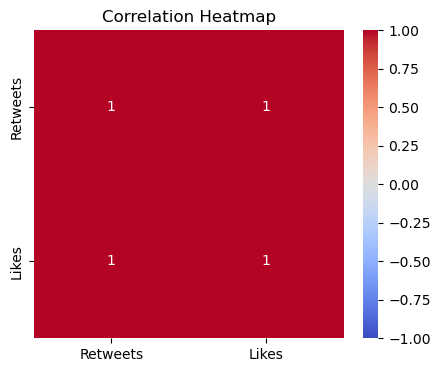

In [20]:
# Correlation between numerical features

corr = df[['Retweets', 'Likes']].corr()
print("Correlation matrix:")
print(corr)

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

C:\Users\RECONCILIATION UNIT\AppData\Local\Temp\ipykernel_9816\3692018661.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


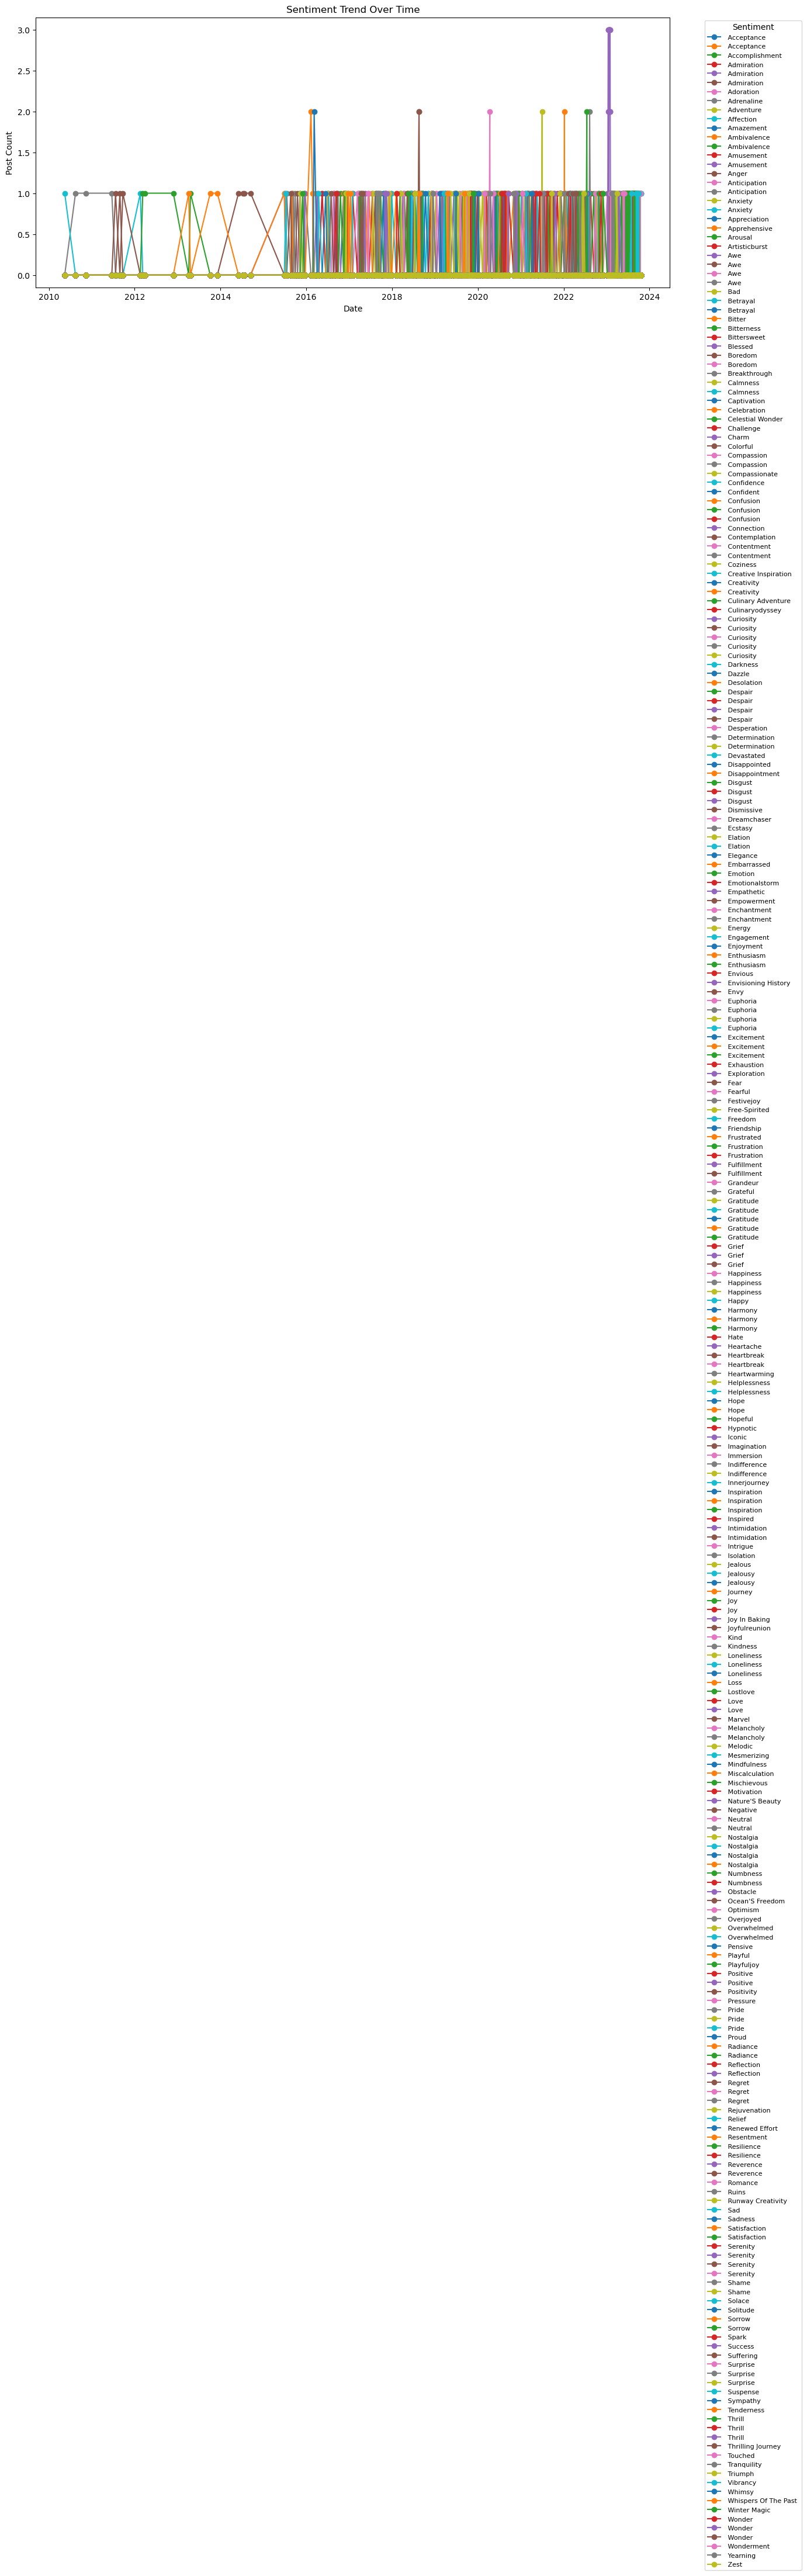

In [21]:
# Bonus: Sentiment distribution over time

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

daily_sentiment = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0)

daily_sentiment.plot(figsize=(14, 6), marker='o')
plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Post Count')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# Level 2 - Task 2: Time Series Analysis

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
# Build a daily time series (post count + total engagement)

df['Date'] = df['Timestamp'].dt.date
df['Date'] = pd.to_datetime(df['Date'])

daily = df.groupby('Date').agg(
    Post_Count=('Text', 'count'),
    Total_Likes=('Likes', 'sum'),
    Total_Retweets=('Retweets', 'sum')
).reset_index()

daily = daily.set_index('Date')

# Make sure every calendar day is present (fill gaps with 0)
daily = daily.asfreq('D', fill_value=0)

print("Number of days in series:", len(daily))
daily.head()

Number of days in series: 4909


,Post_Count,Total_Likes,Total_Retweets
Date,,,
2010-05-15,1,40,20
2010-05-16,0,0,0
2010-05-17,0,0,0
2010-05-18,0,0,0
2010-05-19,0,0,0


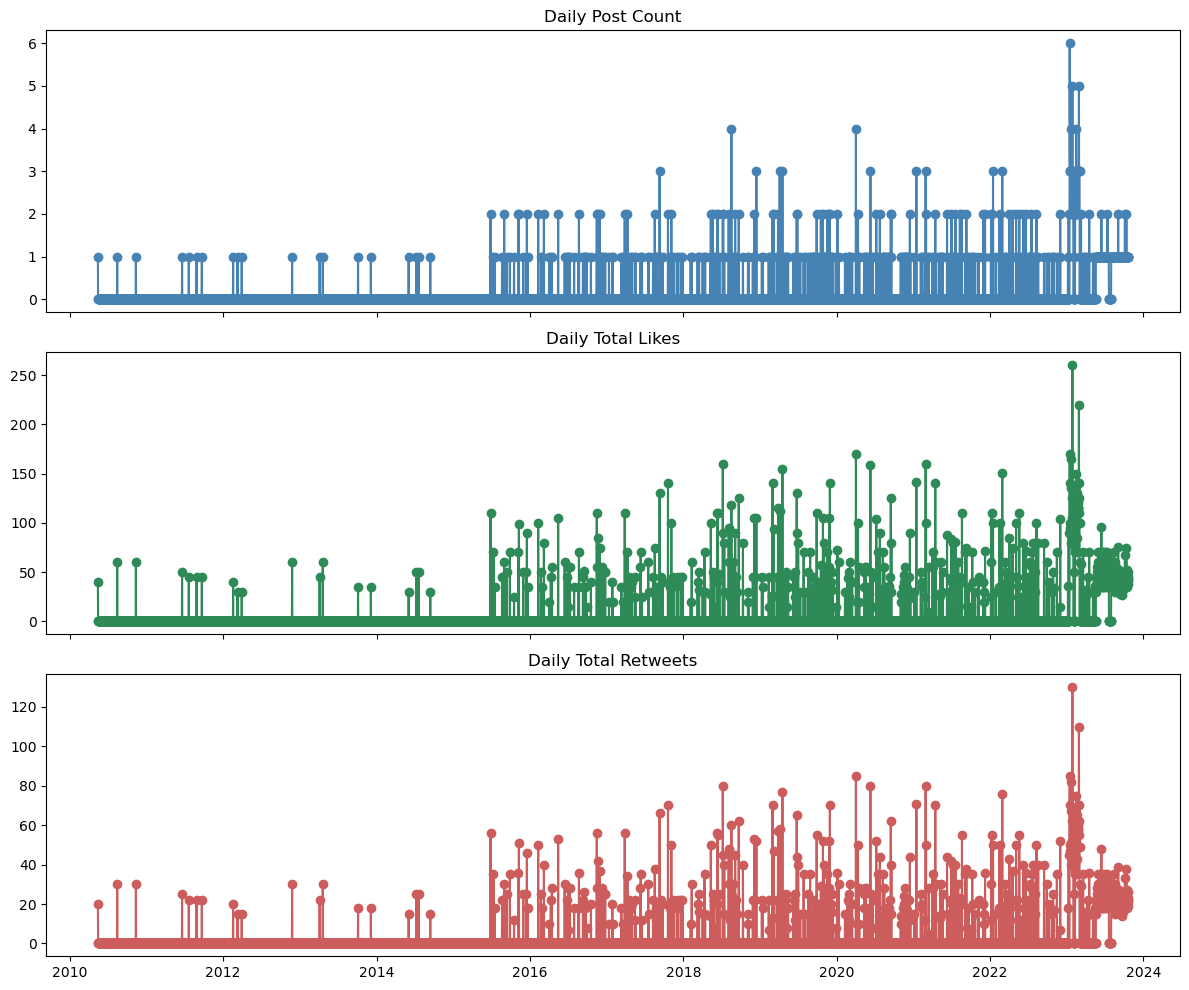

In [25]:
# Plot the time-series data and identify patterns

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(daily.index, daily['Post_Count'], marker='o', color='steelblue')
axes[0].set_title('Daily Post Count')

axes[1].plot(daily.index, daily['Total_Likes'], marker='o', color='seagreen')
axes[1].set_title('Daily Total Likes')

axes[2].plot(daily.index, daily['Total_Retweets'], marker='o', color='indianred')
axes[2].set_title('Daily Total Retweets')

plt.tight_layout()
plt.show()

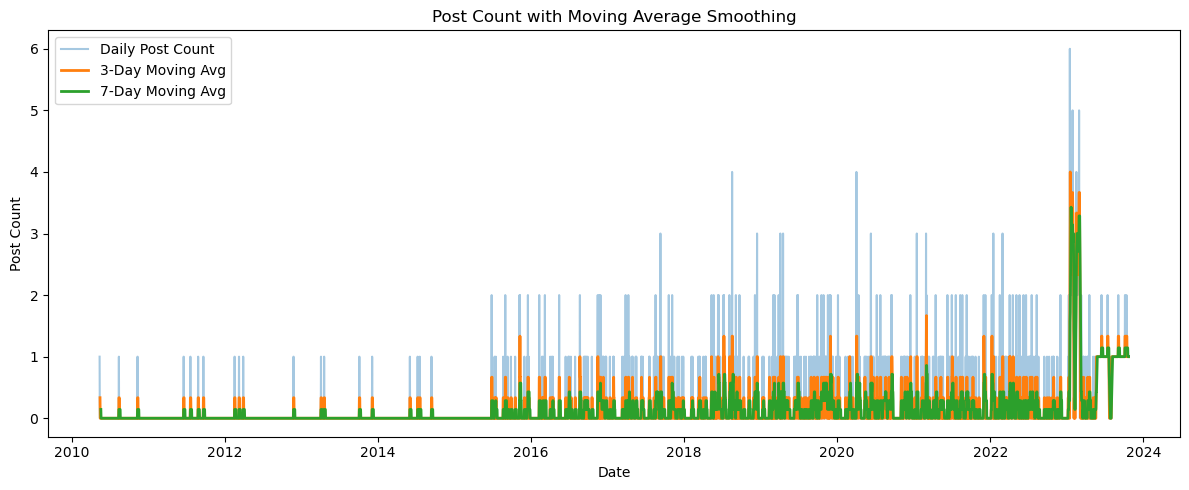

In [26]:
# Moving average smoothing (3-day and 7-day)

daily['Post_Count_MA3'] = daily['Post_Count'].rolling(window=3).mean()
daily['Post_Count_MA7'] = daily['Post_Count'].rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily['Post_Count'], label='Daily Post Count', alpha=0.4)
plt.plot(daily.index, daily['Post_Count_MA3'], label='3-Day Moving Avg', linewidth=2)
plt.plot(daily.index, daily['Post_Count_MA7'], label='7-Day Moving Avg', linewidth=2)
plt.title('Post Count with Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Post Count')
plt.legend()
plt.tight_layout()
plt.show()

Series length: 4909


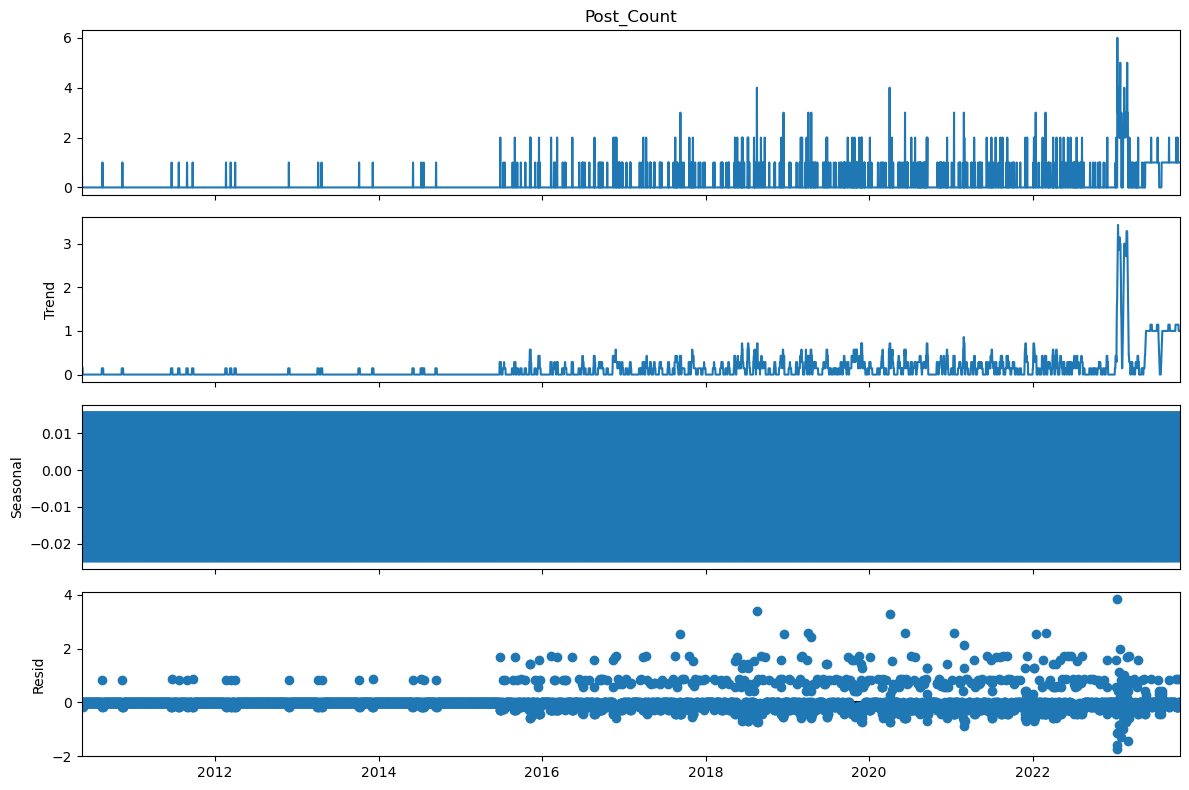

In [27]:
# Seasonal decomposition (trend, seasonality, residuals)

print("Series length:", len(daily))

if len(daily) >= 14:  # need at least 2 full cycles for period=7
    decomposition = seasonal_decompose(daily['Post_Count'], model='additive', period=7)

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data points for weekly decomposition (need >=14 days).")
    print("Consider using a shorter period or aggregating differently.")

In [28]:
# Extract and inspect decomposition components

if len(daily) >= 14:
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    print("Trend component (sample):")
    print(trend.dropna().head())

    print("\nSeasonal component (sample):")
    print(seasonal.head())

    print("\nResidual component (sample):")
    print(residual.dropna().head())

Trend component (sample):
Date
2010-05-18    0.142857
2010-05-19    0.000000
2010-05-20    0.000000
2010-05-21    0.000000
2010-05-22    0.000000
Freq: D, Name: trend, dtype: float64

Seasonal component (sample):
Date
2010-05-15    0.013085
2010-05-16    0.015738
2010-05-17   -0.008752
2010-05-18    0.012251
2010-05-19   -0.024839
Freq: D, Name: seasonal, dtype: float64

Residual component (sample):
Date
2010-05-18   -0.155108
2010-05-19    0.024839
2010-05-20    0.013630
2010-05-21   -0.006146
2010-05-22   -0.013085
Freq: D, Name: resid, dtype: float64


In [29]:
# Level 2 - Task 3: Clustering Analysis (K-Means)

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 

# Features to cluster on (numeric engagement metrics)
features = df[['Retweets', 'Likes']].copy()
print("Shape:", features.shape)
features.describe()

Shape: (712, 2)


,Retweets,Likes
count,712.000000,712.000000
mean,21.542135,42.966292
std,7.124840,14.215995
min,5.000000,10.000000
25%,17.750000,34.750000
50%,22.000000,43.000000
75%,25.000000,50.000000
max,40.000000,80.000000


In [31]:
# Standardize the dataset

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Before scaling (first 5 rows):")
print(features.head())
print("\nAfter scaling (first 5 rows):")
print(scaled_features[:5])

Before scaling (first 5 rows):
   Retweets  Likes
0        15     30
1         5     10
2        20     40
3         8     15
4        12     25

After scaling (first 5 rows):
[[-0.91886051 -0.91273299]
 [-2.32338751 -2.32058804]
 [-0.216597   -0.20880547]
 [-1.90202941 -1.96862428]
 [-1.34021861 -1.26469675]]


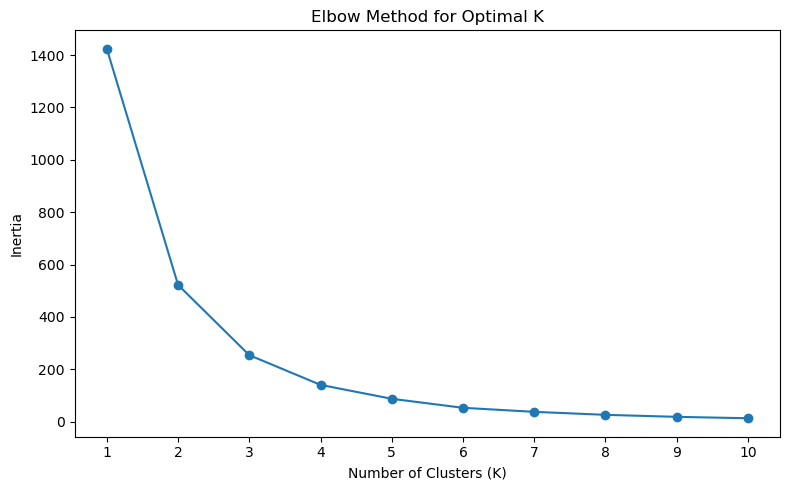

In [32]:
# Elbow method - determine optimal number of clusters

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [33]:
# Apply K-Means with chosen K

optimal_k = 4  # adjust this based on what the elbow chart shows you

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

print("Cluster counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    174
1    291
2     57
3    190
Name: count, dtype: int64


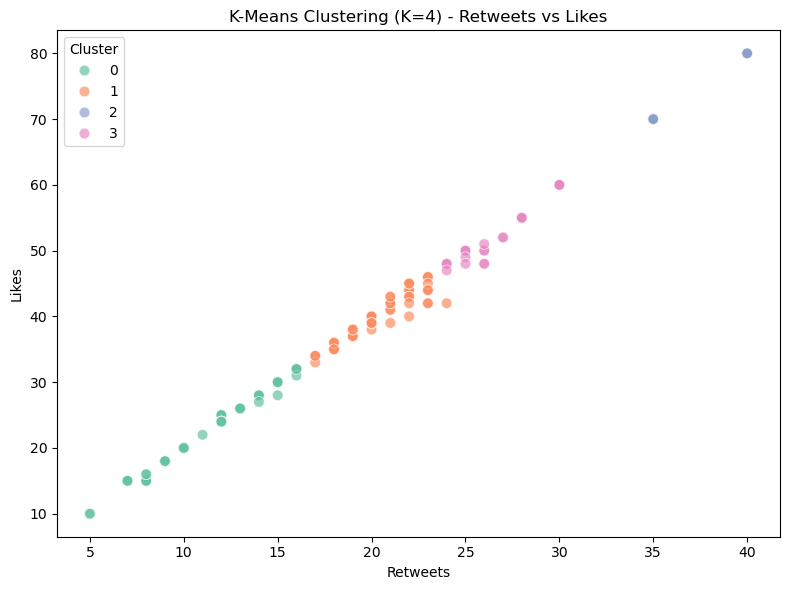

In [34]:
# Visualize clusters - 2D scatter plot

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='Retweets', y='Likes',
    hue='Cluster', palette='Set2', s=60, alpha=0.7
)
plt.title(f'K-Means Clustering (K={optimal_k}) - Retweets vs Likes')
plt.tight_layout()
plt.show()

In [35]:
# Inspect cluster characteristics

cluster_summary = df.groupby('Cluster')[['Retweets', 'Likes']].mean()
print("Average Retweets/Likes per cluster:")
print(cluster_summary)

# Optional: see how clusters relate to Sentiment
print("\nSentiment breakdown per cluster:")
print(pd.crosstab(df['Cluster'], df['Sentiment']).T)

Average Retweets/Likes per cluster:
          Retweets      Likes
Cluster                      
0        12.764368  25.620690
1        20.164948  40.230241
2        36.403509  72.807018
3        27.231579  54.089474

Sentiment breakdown per cluster:
Cluster           0  1  2  3
Sentiment                   
Acceptance        2  1  0  0
Acceptance        2  3  0  0
Accomplishment    0  1  0  2
Admiration        0  1  0  0
Admiration        0  2  0  0
...              .. .. .. ..
Wonder            0  0  1  0
Wonder            0  0  1  0
Wonderment        0  0  1  0
Yearning          2  0  0  0
Zest              2  0  0  0

[279 rows x 4 columns]


In [36]:
# Level 3 - Task 1: Predictive Modeling (Classification)

In [37]:
# Predict Sentiment category from engagement/context features

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Check target variable first

print("Number of unique Sentiment classes:", df['Sentiment'].nunique())
print(df['Sentiment'].value_counts())

Number of unique Sentiment classes: 279
Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Happy              14
                   ..
Dazzle              1
Adrenaline          1
Harmony             1
Artisticburst       1
Elegance            1
Name: count, Length: 279, dtype: int64


In [38]:
# Predict broad Sentiment category (Positive/Negative/Neutral) from engagement/context features

from textblob import TextBlob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Map fine-grained emotion labels to broad Positive/Negative/Neutral

unique_sentiments = df['Sentiment'].unique()

def bucket_sentiment(label):
    polarity = TextBlob(label).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

sentiment_map = {s: bucket_sentiment(s) for s in unique_sentiments}
df['Sentiment_Broad'] = df['Sentiment'].map(sentiment_map)

print("Sample of the mapping:")
for k, v in list(sentiment_map.items())[:15]:
    print(f"  {k} -> {v}")

print("\nBroad sentiment distribution:")
print(df['Sentiment_Broad'].value_counts())

Sample of the mapping:
   Positive   -> Positive
   Negative   -> Negative
   Neutral    -> Neutral
   Anger         -> Negative
   Fear          -> Neutral
   Sadness       -> Neutral
   Disgust       -> Neutral
   Happiness     -> Positive
   Joy           -> Positive
   Love          -> Positive
   Amusement     -> Neutral
   Enjoyment     -> Neutral
   Admiration    -> Neutral
   Affection     -> Neutral
   Awe           -> Neutral

Broad sentiment distribution:
Sentiment_Broad
Neutral     536
Positive    126
Negative     50
Name: count, dtype: int64


In [39]:
# Feature engineering from Timestamp

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0=Monday

# Select features and target

feature_cols = ['Retweets', 'Likes', 'Platform', 'Country', 'Hour', 'DayOfWeek']
X = df[feature_cols].copy()
y = df['Sentiment_Broad'].copy()

print("Feature preview:")
X.head()

Feature preview:


,Retweets,Likes,Platform,Country,Hour,DayOfWeek
0,15,30,Twitter,Usa,12,6
1,5,10,Twitter,Canada,8,6
2,20,40,Instagram,Usa,15,6
3,8,15,Facebook,Uk,18,6
4,12,25,Instagram,Australia,19,6


In [40]:
# Preprocess: encode categoricals, scale numeric

from sklearn.preprocessing import StandardScaler

# One-hot encode Platform and Country
X = pd.get_dummies(X, columns=['Platform', 'Country'], drop_first=True)

# Scale numeric columns
scaler = StandardScaler()
X[['Retweets', 'Likes', 'Hour', 'DayOfWeek']] = scaler.fit_transform(
    X[['Retweets', 'Likes', 'Hour', 'DayOfWeek']]
)

print("Final feature shape:", X.shape)
X.head()

Final feature shape: (712, 121)


,Retweets,Likes,Hour,DayOfWeek,Platform_ Instagram,Platform_ Twitter,Platform_ Twitter,Country_ Australia,Country_ Australia,Country_ Australia,...,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_ Usa,Country_Usa
0,-0.918861,-0.912733,-0.884917,1.420806,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,-2.323388,-2.320588,-1.870157,1.420806,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.216597,-0.208805,-0.145987,1.420806,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,-1.902029,-1.968624,0.592943,1.420806,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.340219,-1.264697,0.839253,1.420806,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
# Encode target and split into train/test

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Classes: ['Negative' 'Neutral' 'Positive']
Train shape: (569, 121) Test shape: (143, 121)


In [42]:
# Train multiple classification models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        10
     Neutral       0.76      0.96      0.85       108
    Positive       0.50      0.12      0.19        25

    accuracy                           0.75       143
   macro avg       0.42      0.36      0.35       143
weighted avg       0.66      0.75      0.68       143


--- Decision Tree ---
              precision    recall  f1-score   support

    Negative       0.43      0.30      0.35        10
     Neutral       0.80      0.81      0.80       108
    Positive       0.30      0.32      0.31        25

    accuracy                           0.69       143
   macro avg       0.51      0.48      0.49       143
weighted avg       0.68      0.69      0.68       143


--- Random Forest ---
              precision    recall  f1-score   support

    Negative       0.25      0.10      0.14        10
     Neutral       0.77      0.92      0.84       108
 

Model comparison:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.748252   0.664953  0.748252  0.677652
Decision Tree        0.685315   0.684580  0.685315  0.684062
Random Forest        0.713287   0.633404  0.713287  0.663053


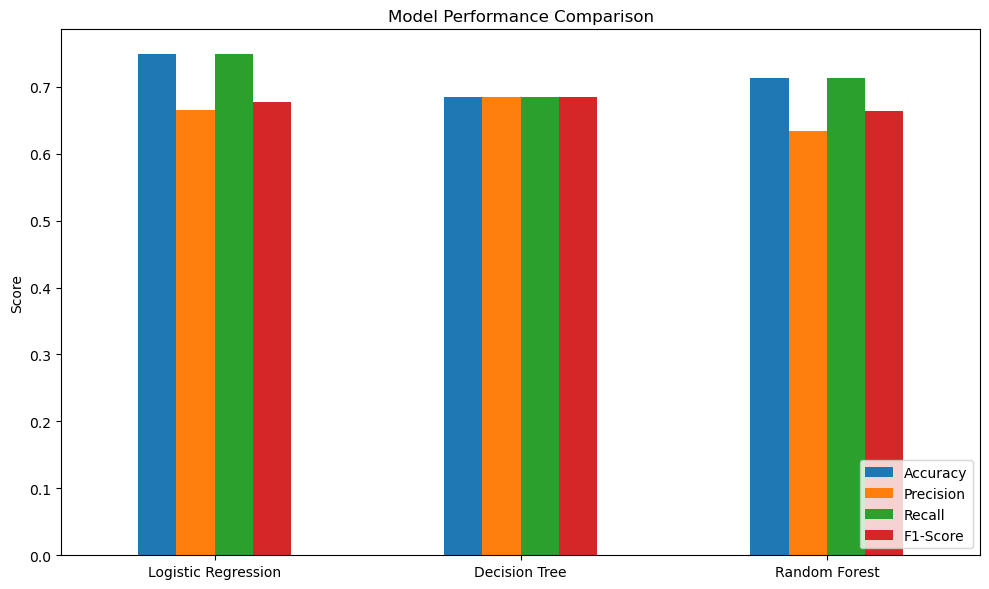

In [43]:
# Compare model performance

results_df = pd.DataFrame(results).T
print("Model comparison:")
print(results_df)

results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [44]:
# Hyperparameter tuning with Grid Search (Random Forest)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

# Evaluate tuned model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\nTuned Random Forest performance on test set:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_, zero_division=0))

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.6937262780746296

Tuned Random Forest performance on test set:
              precision    recall  f1-score   support

    Negative       0.25      0.10      0.14        10
     Neutral       0.77      0.94      0.85       108
    Positive       0.14      0.04      0.06        25

    accuracy                           0.73       143
   macro avg       0.39      0.36      0.35       143
weighted avg       0.63      0.73      0.66       143



In [45]:
# Level 3 - Task 3: NLP - Sentiment Analysis

In [46]:
import nltk
import re
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# One-time downloads (safe to re-run, will skip if already present)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [47]:
# Preprocess text: lowercase, remove noise, tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove mentions
    text = re.sub(r'#', '', text)                     # remove hashtag symbol (keep word)
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation/numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['Clean_Text'] = df['Text'].apply(clean_text)

print("Before/after example:")
print("Original:", df['Text'].iloc[0])
print("Cleaned: ", df['Clean_Text'].iloc[0])

Before/after example:
Original:  Enjoying a beautiful day at the park!              
Cleaned:  enjoying beautiful day park


In [48]:
# Sentiment analysis with TextBlob

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def classify_polarity(p):
    if p > 0.1:
        return 'Positive'
    elif p < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['Polarity'] = df['Clean_Text'].apply(get_polarity)
df['Predicted_Sentiment'] = df['Polarity'].apply(classify_polarity)

print(df[['Text', 'Polarity', 'Predicted_Sentiment']].head(10))

                                                Text  Polarity  \
0   Enjoying a beautiful day at the park!        ...  0.675000   
1   Traffic was terrible this morning.           ... -1.000000   
2   Just finished an amazing workout! 💪          ...  0.600000   
3   Excited about the upcoming weekend getaway!  ...  0.375000   
4   Trying out a new recipe for dinner tonight.  ...  0.136364   
5   Feeling grateful for the little things in lif... -0.187500   
6   Rainy days call for cozy blankets and hot coc...  0.025000   
7   The new movie release is a must-watch!       ...  0.136364   
8   Political discussions heating up on the timel...  0.000000   
9   Missing summer vibes and beach days.         ... -0.200000   

  Predicted_Sentiment  
0            Positive  
1            Negative  
2            Positive  
3            Positive  
4            Positive  
5            Negative  
6             Neutral  
7            Positive  
8             Neutral  
9            Negative  


In [49]:
# Compare predicted vs. broad ground-truth sentiment

from sklearn.metrics import accuracy_score, classification_report

comparison = df[['Sentiment_Broad', 'Predicted_Sentiment']].dropna()

print("Agreement between TextBlob prediction and labeled sentiment:")
print("Accuracy:", accuracy_score(comparison['Sentiment_Broad'], comparison['Predicted_Sentiment']))
print()
print(classification_report(comparison['Sentiment_Broad'], comparison['Predicted_Sentiment']))

Agreement between TextBlob prediction and labeled sentiment:
Accuracy: 0.601123595505618

              precision    recall  f1-score   support

    Negative       0.38      0.64      0.48        50
     Neutral       0.84      0.61      0.70       536
    Positive       0.30      0.56      0.39       126

    accuracy                           0.60       712
   macro avg       0.50      0.60      0.52       712
weighted avg       0.71      0.60      0.63       712



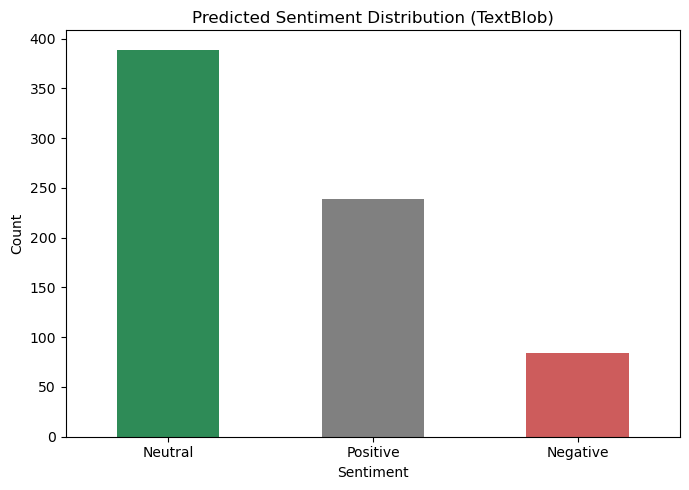

In [50]:
# Visualize sentiment distribution

plt.figure(figsize=(7, 5))
df['Predicted_Sentiment'].value_counts().plot(kind='bar', color=['seagreen', 'gray', 'indianred'])
plt.title('Predicted Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

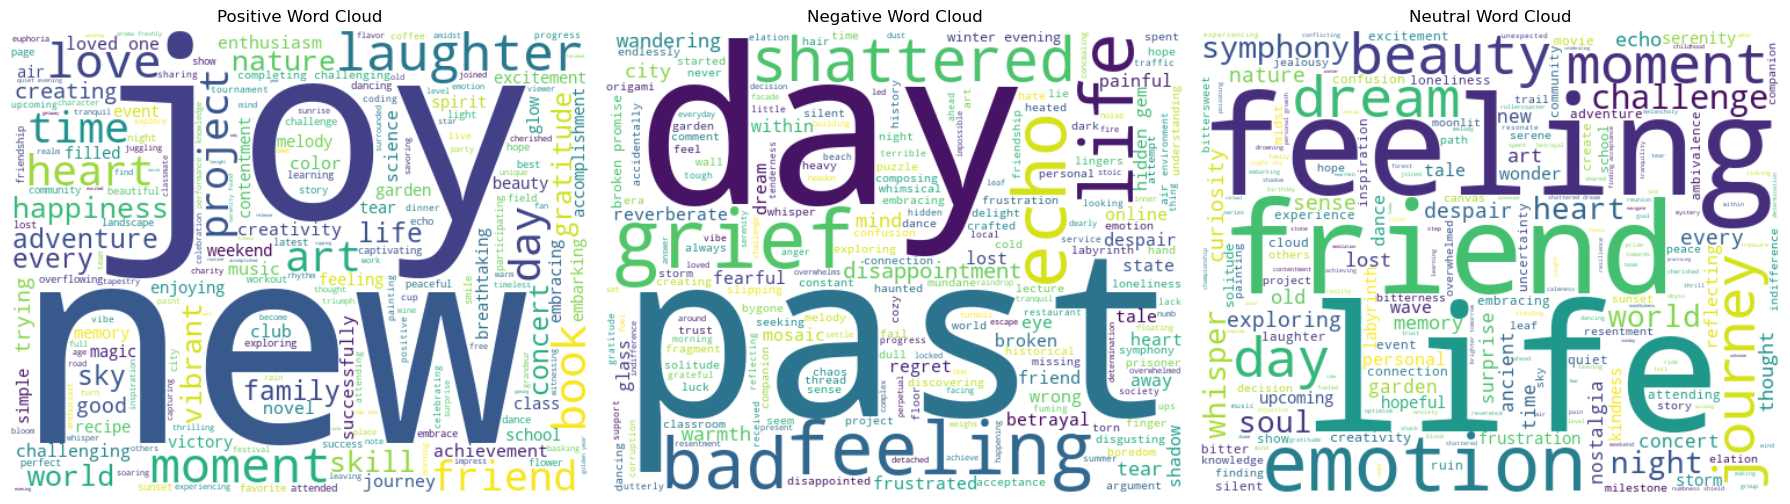

In [51]:
# Word clouds per sentiment class

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    text_blob = ' '.join(df[df['Predicted_Sentiment'] == sentiment]['Clean_Text'])
    if text_blob.strip():
        wc = WordCloud(width=500, height=400, background_color='white').generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Word Cloud')
    ax.axis('off')

plt.tight_layout()
plt.show()

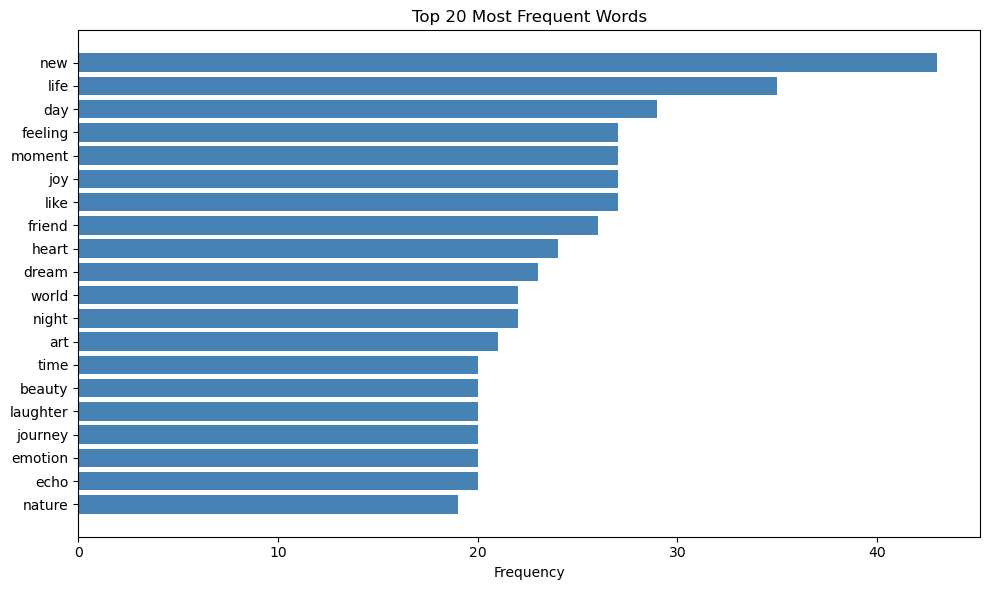

In [52]:
# Overall word frequency (top 20 words)

from collections import Counter

all_words = ' '.join(df['Clean_Text']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()